In [ ]:
import polars as pl

data = pl.read_csv("train_dataset.tsv", separator="\t")
# data_synth = pl.read_csv("synthetic.csv")
# data = pl.concat([data, data_synth])
data.head(5), data.shape

(shape: (5, 3)
 ┌─────────────────────────────────┬──────────────────────────┬─────────────────────────────────┐
 │ text                            ┆ target                   ┆ entity                          │
 │ ---                             ┆ ---                      ┆ ---                             │
 │ str                             ┆ str                      ┆ str                             │
 ╞═════════════════════════════════╪══════════════════════════╪═════════════════════════════════╡
 │ Вы можете обновить client secr… ┆ []                       ┆ empty                           │
 │ Возможно, произошел временный … ┆ []                       ┆ empty                           │
 │ Наши запросы с API ключом bk_a… ┆ [(26, 69, 'API ключи')]  ┆ ['bk_api_key_ABCDEF1234567890A… │
 │ Сгенерируйте новый JWT для сер… ┆ []                       ┆ empty                           │
 │ Возможно, токен 6363069502:y-3… ┆ [(16, 100, 'API ключи')] ┆ ['6363069502:y-3-y-6-z-0-w-5-w… │
 └───

# Весь

In [ ]:
# Извлекаем метки из target средствами Polars
# target содержит строки вида "[(26, 69, 'API ключи')]" — извлекаем только названия меток
labels = (
    data
    .filter(pl.col("target") != "[]")
    .select(
        pl.col("target")
        .str.extract_all(r"'([^']+)'")
        .explode()
        .alias("label")
    )
)

# Распределение меток
label_counts = (
    labels
    .group_by("label")
    .len()
    .sort("len", descending=True)
)

print(f"Всего уникальных меток: {label_counts.shape[0]}\n")
print("Распределение меток:")
print(label_counts)

# Строки без меток
empty_count = data.filter(pl.col("target") == "[]").shape[0]
print(f"\nСтрок без меток: {empty_count} из {data.shape[0]} ({empty_count/data.shape[0]*100:.1f}%)")


Всего уникальных меток: 30

Распределение меток:
shape: (30, 2)
┌─────────────────────────────────┬─────┐
│ label                           ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ 'Полный адрес'                  ┆ 811 │
│ 'Дата рождения'                 ┆ 362 │
│ 'API ключи'                     ┆ 337 │
│ 'Гражданство и названия стран'  ┆ 333 │
│ 'Место рождения'                ┆ 324 │
│ …                               ┆ …   │
│ 'Одноразовые коды'              ┆ 139 │
│ 'Свидетельство о рождении'      ┆ 138 │
│ 'СНИЛС клиента'                 ┆ 133 │
│ 'Email'                         ┆ 129 │
│ 'Серия и номер вида на жительс… ┆ 104 │
└─────────────────────────────────┴─────┘

Строк без меток: 2586 из 8287 (31.2%)


In [ ]:
import re

# Маппинг метка -> int (strip кавычек, т.к. extract_all возвращает полный матч)
unique_labels = sorted(lb.strip("'") for lb in label_counts["label"].to_list())
label2id = {label: i for i, label in enumerate(unique_labels)}

pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")

data = data.with_columns(
    pl.col("target").map_elements(
        lambda s: [[int(a), int(b), label2id[c]] for a, b, c in pattern.findall(s)],
        return_dtype=pl.List(pl.List(pl.Int64))
    ).alias("target")
)

print(data.select("text", "target").head(10))

shape: (10, 2)
┌─────────────────────────────────┬─────────────────┐
│ text                            ┆ target          │
│ ---                             ┆ ---             │
│ str                             ┆ list[list[i64]] │
╞═════════════════════════════════╪═════════════════╡
│ Вы можете обновить client secr… ┆ []              │
│ Возможно, произошел временный … ┆ []              │
│ Наши запросы с API ключом bk_a… ┆ [[26, 69, 0]]   │
│ Сгенерируйте новый JWT для сер… ┆ []              │
│ Возможно, токен 6363069502:y-3… ┆ [[16, 100, 0]]  │
│ Мне нужен API ключ для интегра… ┆ []              │
│ Пожалуйста, попробуйте переген… ┆ []              │
│ Наш внутренний бот перестал от… ┆ [[44, 90, 0]]   │
│ Убедитесь, что для Google Clou… ┆ [[40, 122, 0]]  │
│ Я не могу получить выписку по … ┆ [[57, 81, 0]]   │
└─────────────────────────────────┴─────────────────┘


In [ ]:
id2label = {v: k for k, v in label2id.items()}

label_dist = (
    data.select(pl.col("target").explode().alias("span"))
    .filter(pl.col("span").is_not_null())
    .select(pl.col("span").list.get(2).alias("label_id"))
    .group_by("label_id")
    .len()
    .sort("len", descending=True)
    .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
    .select("label_id", "label", "len")
)

print(f"Уникальных меток: {label_dist.shape[0]}")
print(f"Строк без меток: {data['target'].is_null().sum()}\n")
print(label_dist)


Уникальных меток: 30
Строк без меток: 0

shape: (30, 3)
┌──────────┬─────────────────────────────────┬─────┐
│ label_id ┆ label                           ┆ len │
│ ---      ┆ ---                             ┆ --- │
│ i64      ┆ str                             ┆ u32 │
╞══════════╪═════════════════════════════════╪═════╡
│ 22       ┆ Полный адрес                    ┆ 811 │
│ 10       ┆ Дата рождения                   ┆ 362 │
│ 0        ┆ API ключи                       ┆ 337 │
│ 5        ┆ Гражданство и названия стран    ┆ 333 │
│ 13       ┆ Место рождения                  ┆ 324 │
│ …        ┆ …                               ┆ …   │
│ 18       ┆ Одноразовые коды                ┆ 139 │
│ 26       ┆ Свидетельство о рождении        ┆ 138 │
│ 24       ┆ СНИЛС клиента                   ┆ 133 │
│ 2        ┆ Email                           ┆ 129 │
│ 27       ┆ Серия и номер вида на жительст… ┆ 104 │
└──────────┴─────────────────────────────────┴─────┘


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH  = 512
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 5e-4

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# ── BIO label set ────────────────────────────────────────────────────────────
bio_labels   = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
num_ner_labels = len(bio_labels)

print(f"device: {DEVICE} | NER labels: {num_ner_labels}")


# ── Dataset ──────────────────────────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts   = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx], self.targets[idx]


# ── Collate ──────────────────────────────────────────────────────────────────
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offset_mappings = encoded.pop("offset_mapping")

    token_labels_batch, binary_labels_batch = [], []
    for spans, offsets in zip(targets, offset_mappings):
        binary_labels_batch.append(1 if spans else 0)
        token_labels = []
        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue
            label = bio_label2id["O"]
            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name  = unique_labels[label_id]
                    label = bio_label2id[f"B-{name}" if tok_start <= span_start else f"I-{name}"]
                    break
            token_labels.append(label)
        token_labels_batch.append(token_labels)

    encoded["labels"]        = torch.tensor(token_labels_batch,  dtype=torch.long)
    encoded["binary_labels"] = torch.tensor(binary_labels_batch, dtype=torch.long)
    return encoded


# ── Model ─────────────────────────────────────────────────────────────────────
class MultiTaskNER(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.ner_head = nn.Linear(h, num_ner_labels)
        self.cls_head = nn.Linear(h, 2)

    def forward(self, input_ids, attention_mask, labels=None, binary_labels=None, **kwargs):
        hidden     = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        ner_logits = self.ner_head(hidden)       # (B, T, num_ner_labels)
        cls_logits = self.cls_head(hidden[:, 0]) # (B, 2)

        loss = None
        if labels is not None:
            cls_loss = nn.CrossEntropyLoss(ignore_index=-100)(cls_logits, binary_labels)

            pos_mask = binary_labels == 1
            if pos_mask.any():
                ner_loss = nn.CrossEntropyLoss(ignore_index=-100)(
                    ner_logits[pos_mask].reshape(-1, num_ner_labels),
                    labels[pos_mask].reshape(-1),
                )
                loss = cls_loss + ner_loss
            else:
                loss = cls_loss

        return {"loss": loss, "ner_logits": ner_logits, "cls_logits": cls_logits}


device: cuda | NER labels: 61


In [ ]:
model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)

def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    if freeze_embeddings:
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    for i, layer in enumerate(model.encoder.transformer.layer):
        if i < freeze_n_layers:
            for p in layer.parameters():
                p.requires_grad = False

def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")
    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")

freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3)
print_trainable_parameters(model)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TRAINABLE: encoder.transformer.layer.3.attention.q_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.q_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.k_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.k_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.v_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.v_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.out_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.out_lin.bias
TRAINABLE: encoder.transformer.layer.3.sa_layer_norm.weight
TRAINABLE: encoder.transformer.layer.3.sa_layer_norm.bias
TRAINABLE: encoder.transformer.layer.3.ffn.lin1.weight
TRAINABLE: encoder.transformer.layer.3.ffn.lin1.bias
TRAINABLE: encoder.transformer.layer.3.ffn.lin2.weight
TRAINABLE: encoder.transformer.layer.3.ffn.lin2.bias
TRAINABLE: encoder.transformer.layer.3.output_layer_norm.weight
TRAINABLE: encoder.transformer.layer.3.output_layer_norm.bias
TRAINABLE: encoder.transformer.layer.4.attention

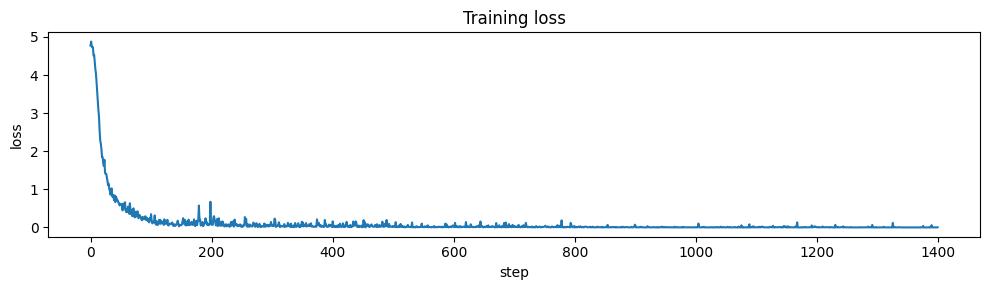

Epoch 11/15 | step 100/130 | loss 0.0053
── Epoch 11/15 avg loss: 0.0039


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

PLOT_EVERY = 50

# ── Data & training ───────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset   = NERDataset(data["text"].to_list(), data["target"].to_list())
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

#model     = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)
#optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)

loss_history = []

def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        loss  = model(**batch)["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        total_loss += loss.item()

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(loss_history)
            print(f"Epoch {epoch+1}/{EPOCHS} | step {step+1}/{len(dataloader)} | loss {loss.item():.4f}")

    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {total_loss / len(dataloader):.4f}")

plot_loss(loss_history)


In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
model.load_state_dict(torch.load("model.pth"))

In [ ]:
df = pl.read_csv("private_test_dataset.csv")
df.head(5), df.shape

In [ ]:
model.eval()


def decode_triplets(pred_ids, offsets, attention_mask):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = bio_labels[int(pred_id)]
        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets


@torch.no_grad()
def predict_triplets(texts, batch_size=64):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]
        batch = {k: v.to(DEVICE) for k, v in encoded.items()}

        outputs = model(**batch)
        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
        cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

        for has_entity, pred_ids, offsets, mask in zip(
            cls_pred_ids.tolist(),
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            if has_entity == 0:
                all_triplets.append([])
                continue

            all_triplets.append(decode_triplets(pred_ids, offsets, mask))

    return all_triplets


pred_triplets = predict_triplets(df["text"].to_list())

# offset_mapping уже даёт символьные индексы токенов в исходной строке,
# поэтому для ответа берём первый start и последний end у непрерывного BIO-спана.
def format_prediction(triplets):
    if not triplets:
        return '[]'
    parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
    return f'[{", ".join(parts)}]'


formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

In [ ]:
submission_df.drop("text").write_csv("predictions.csv")
submission_df.head(10)

In [ ]:
# def extract_entities_from_text(text, triplets):
#     return [
#         (int(start), int(end), str(label), text[int(start):int(end)])
#         for start, end, label in triplets
#     ]


# entity_examples = [
#     extract_entities_from_text(text, triplets)
#     for text, triplets in zip(df["text"].to_list(), pred_triplets)
# ]

# df_with_entities = df.select("id", "text").with_columns(
#     pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8),
#     pl.Series("predicted_entities", [str(x) for x in entity_examples], dtype=pl.Utf8)
# )

# (
#     df_with_entities
#     .filter(pl.col("Prediction") != "[]")
#     .select("id", "text", "Prediction", "predicted_entities")
#     .head(10)
# )

# Valid

In [ ]:
!pip install iterative-stratification

In [ ]:
import numpy as np
import polars as pl
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [ ]:
# targets как python-списки
texts_list   = data["text"].to_list()
targets_list = data["target"].to_list()

n_samples = len(targets_list)
n_labels  = len(unique_labels)

# multilabel matrix: [n_samples, n_labels]
Y_multi = np.zeros((n_samples, n_labels), dtype=np.int32)

for i, spans in enumerate(targets_list):
    if spans:
        present_labels = set(span[2] for span in spans)
        for lid in present_labels:
            Y_multi[i, lid] = 1

print("Y_multi shape:", Y_multi.shape)
print("Rows with no labels:", (Y_multi.sum(axis=1) == 0).sum())

In [ ]:
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

idx = np.arange(n_samples)
train_idx, valid_idx = next(msss.split(idx.reshape(-1, 1), Y_multi))

train_data = data[train_idx.tolist()]
valid_data = data[valid_idx.tolist()]

print("train shape:", train_data.shape)
print("valid shape:", valid_data.shape)

In [ ]:
def build_label_distribution(df, id2label):
    dist = (
        df.select(pl.col("target").explode().alias("span"))
        .filter(pl.col("span").is_not_null())
        .select(pl.col("span").list.get(2).alias("label_id"))
        .group_by("label_id")
        .len()
        .sort("label_id")
        .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
        .select("label_id", "label", "len")
    )
    return dist

train_label_dist = build_label_distribution(train_data, id2label).rename({"len": "train_count"})
valid_label_dist = build_label_distribution(valid_data, id2label).rename({"len": "valid_count"})

dist_compare = (
    train_label_dist.join(valid_label_dist, on=["label_id", "label"], how="full")
    .fill_null(0)
    .with_columns(
        (pl.col("train_count") / pl.col("train_count").sum()).alias("train_share"),
        (pl.col("valid_count") / pl.col("valid_count").sum()).alias("valid_share"),
    )
    .sort("label_id")
)

print(dist_compare)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH = 512
BATCH_SIZE = 64
EPOCHS     = 15
LR         = 5e-5   # 5e-4 для BERT-подобных обычно слишком агрессивно

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

bio_labels   = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
bio_id2label = {v: k for k, v in bio_label2id.items()}
num_ner_labels = len(bio_labels)

print(f"device: {DEVICE} | NER labels: {num_ner_labels}")

In [ ]:
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

In [ ]:
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )

    offset_mappings = encoded["offset_mapping"].clone()

    token_labels_batch = []
    binary_labels_batch = []

    for spans, offsets in zip(targets, offset_mappings):
        binary_labels_batch.append(1 if spans else 0)

        token_labels = []
        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue

            label = bio_label2id["O"]

            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name = unique_labels[label_id]
                    prefix = "B" if tok_start <= span_start else "I"
                    label = bio_label2id[f"{prefix}-{name}"]
                    break

            token_labels.append(label)

        token_labels_batch.append(token_labels)

    encoded["labels"] = torch.tensor(token_labels_batch, dtype=torch.long)
    encoded["binary_labels"] = torch.tensor(binary_labels_batch, dtype=torch.long)

    # для валидации оставляем как есть
    encoded["texts"] = list(texts)
    encoded["targets"] = list(targets)
    encoded["offset_mapping"] = offset_mappings

    return encoded

In [ ]:
class MultiTaskNER(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.ner_head = nn.Linear(h, num_ner_labels)
        self.cls_head = nn.Linear(h, 2)

    def forward(self, input_ids, attention_mask, labels=None, binary_labels=None, **kwargs):
        hidden = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        ner_logits = self.ner_head(hidden)       # (B, T, C)
        cls_logits = self.cls_head(hidden[:, 0]) # (B, 2)

        loss = None
        if labels is not None and binary_labels is not None:
            cls_loss = nn.CrossEntropyLoss()(cls_logits, binary_labels)

            pos_mask = binary_labels == 1
            if pos_mask.any():
                ner_loss = nn.CrossEntropyLoss(ignore_index=-100)(
                    ner_logits[pos_mask].reshape(-1, num_ner_labels),
                    labels[pos_mask].reshape(-1),
                )
                loss = cls_loss + ner_loss
            else:
                loss = cls_loss

        return {
            "loss": loss,
            "ner_logits": ner_logits,
            "cls_logits": cls_logits
        }

In [ ]:
model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)

def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=2):
    if freeze_embeddings:
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    for i, layer in enumerate(model.encoder.transformer.layer):
        if i < freeze_n_layers:
            for p in layer.parameters():
                p.requires_grad = False

def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")
    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")

freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=2)
print_trainable_parameters(model)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = NERDataset(
    train_data["text"].to_list(),
    train_data["target"].to_list()
)

valid_dataset = NERDataset(
    valid_data["text"].to_list(),
    valid_data["target"].to_list()
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

In [ ]:
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01
)

total_steps = len(train_dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

In [ ]:
from collections import defaultdict
import pandas as pd

In [ ]:
def decode_bio_to_spans(pred_ids, offsets, attention_mask, bio_id2label):
    spans = []
    active_label = None
    active_start = None
    active_end = None

    seq_len = len(pred_ids)

    for i in range(seq_len):
        if attention_mask[i] == 0:
            break

        tok_start, tok_end = offsets[i]
        if tok_start == tok_end:
            continue

        tag = bio_id2label[int(pred_ids[i])]

        if tag == "O":
            if active_label is not None:
                spans.append((active_start, active_end, active_label))
                active_label = None
                active_start = None
                active_end = None
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            if active_label is not None:
                spans.append((active_start, active_end, active_label))
            active_label = label
            active_start = tok_start
            active_end = tok_end

        elif prefix == "I":
            if active_label == label:
                active_end = tok_end
            else:
                if active_label is not None:
                    spans.append((active_start, active_end, active_label))
                active_label = label
                active_start = tok_start
                active_end = tok_end

    if active_label is not None:
        spans.append((active_start, active_end, active_label))

    return spans

In [ ]:
def compute_span_metrics(all_true_spans, all_pred_spans, unique_labels):
    per_label = {}

    micro_tp = micro_fp = micro_fn = 0

    for label in unique_labels:
        tp = fp = fn = 0

        for true_spans, pred_spans in zip(all_true_spans, all_pred_spans):
            true_set = {(s, e, l) for s, e, l in true_spans if l == label}
            pred_set = {(s, e, l) for s, e, l in pred_spans if l == label}

            tp += len(true_set & pred_set)
            fp += len(pred_set - true_set)
            fn += len(true_set - pred_set)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn

        per_label[label] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

        micro_tp += tp
        micro_fp += fp
        micro_fn += fn

    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0

    macro_f1 = np.mean([v["f1"] for v in per_label.values()]) if per_label else 0.0

    total_support = sum(v["support"] for v in per_label.values())
    weighted_f1 = (
        sum(v["f1"] * v["support"] for v in per_label.values()) / total_support
        if total_support > 0 else 0.0
    )

    summary = {
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

    return summary, per_label

In [ ]:
@torch.no_grad()
def evaluate_model(model, dataloader, bio_id2label, unique_labels, device):
    model.eval()

    total_loss = 0.0
    steps = 0

    all_true_spans = []
    all_pred_spans = []

    cls_true = []
    cls_pred = []

    for batch in dataloader:
        texts = batch.pop("texts")
        targets = batch.pop("targets")
        offset_mapping = batch["offset_mapping"]

        batch_torch = {}
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch_torch[k] = v.to(device)

        outputs = model(**batch_torch)
        loss = outputs["loss"]
        if loss is not None:
            total_loss += loss.item()
            steps += 1

        ner_preds = outputs["ner_logits"].argmax(dim=-1).cpu().numpy()
        cls_preds = outputs["cls_logits"].argmax(dim=-1).cpu().numpy()

        attention_mask = batch["attention_mask"].cpu().numpy()
        offsets = offset_mapping.cpu().numpy()

        cls_true.extend(batch["binary_labels"].cpu().numpy().tolist())
        cls_pred.extend(cls_preds.tolist())

        for i in range(len(texts)):
            pred_spans = decode_bio_to_spans(
                pred_ids=ner_preds[i],
                offsets=offsets[i],
                attention_mask=attention_mask[i],
                bio_id2label=bio_id2label
            )

            true_spans = [
                (span_start, span_end, unique_labels[label_id])
                for span_start, span_end, label_id in targets[i]
            ]

            all_true_spans.append(true_spans)
            all_pred_spans.append(pred_spans)

    summary, per_label = compute_span_metrics(all_true_spans, all_pred_spans, unique_labels)

    cls_true = np.array(cls_true)
    cls_pred = np.array(cls_pred)

    cls_acc = (cls_true == cls_pred).mean() if len(cls_true) > 0 else 0.0

    result = {
        "valid_loss": total_loss / max(steps, 1),
        "cls_acc": cls_acc,
        **summary
    }

    model.train()
    return result, per_label

In [ ]:
def per_label_to_df(per_label_metrics):
    df = (
        pd.DataFrame(per_label_metrics)
        .T
        .reset_index()
        .rename(columns={"index": "label"})
        .sort_values(["f1", "support"], ascending=[False, False])
        .reset_index(drop=True)
    )
    return df

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
PLOT_EVERY = 50
loss_history = []
valid_history = []

def plot_training_curves(loss_history, valid_history):
    clear_output(wait=True)

    plt.figure(figsize=(12, 4))
    plt.plot(loss_history, label="train loss (step)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(valid_history) > 0:
        plt.figure(figsize=(12, 4))
        plt.plot([x["epoch"] for x in valid_history], [x["valid_loss"] for x in valid_history], label="valid_loss")
        plt.plot([x["epoch"] for x in valid_history], [x["micro_f1"] for x in valid_history], label="micro_f1")
        plt.plot([x["epoch"] for x in valid_history], [x["macro_f1"] for x in valid_history], label="macro_f1")
        plt.xlabel("epoch")
        plt.ylabel("metric")
        plt.title("Validation metrics")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
best_micro_f1 = -1.0
best_state_dict = None
best_per_label_df = None

model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0

    for step, batch in enumerate(train_dataloader):
        batch.pop("texts")
        batch.pop("targets")
        batch.pop("offset_mapping")

        batch = {
            k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }

        outputs = model(**batch)
        loss = outputs["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        total_loss += loss.item()

        if (step + 1) % PLOT_EVERY == 0:
            plot_training_curves(loss_history, valid_history)
            print(f"Epoch {epoch+1}/{EPOCHS} | step {step+1}/{len(train_dataloader)} | train_loss {loss.item():.4f}")

    train_epoch_loss = total_loss / len(train_dataloader)

    valid_metrics, per_label_metrics = evaluate_model(
        model=model,
        dataloader=valid_dataloader,
        bio_id2label=bio_id2label,
        unique_labels=unique_labels,
        device=DEVICE
    )

    valid_history.append({
        "epoch": epoch + 1,
        **valid_metrics
    })

    per_label_df = per_label_to_df(per_label_metrics)

    plot_training_curves(loss_history, valid_history)

    print(f"\n── Epoch {epoch+1}/{EPOCHS}")
    print(f"train_loss   : {train_epoch_loss:.4f}")
    print(f"valid_loss   : {valid_metrics['valid_loss']:.4f}")
    print(f"cls_acc      : {valid_metrics['cls_acc']:.4f}")
    print(f"micro_f1     : {valid_metrics['micro_f1']:.4f}")
    print(f"macro_f1     : {valid_metrics['macro_f1']:.4f}")
    print(f"weighted_f1  : {valid_metrics['weighted_f1']:.4f}")

    print("\nTop-15 classes by F1 on valid:")
    print(per_label_df.head(15))

    if valid_metrics["micro_f1"] > best_micro_f1:
        best_micro_f1 = valid_metrics["micro_f1"]
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_per_label_df = per_label_df.copy()
        print("\n✅ Best model updated")

In [ ]:
print(f"Best valid micro_f1: {best_micro_f1:.4f}")
best_per_label_df

In [ ]:
torch.save(
    {
        "model_state_dict": best_state_dict,
        "label2id": label2id,
        "id2label": id2label,
        "bio_label2id": bio_label2id,
        "bio_id2label": bio_id2label,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
    },
    "best_multitask_ner.pt"
)

print("Model saved to best_multitask_ner.pt")